# GPS Comparison

**Author:** Jonah Lee

**Date:** 2026-04-05

**Relevant Links:**
- [Phone GPS Logger Monday Update](https://ubcsolar26.monday.com/boards/9565353662/pulses/9773051025/posts/5062100496)
- [Phone GPS Logger Project](https://github.com/UBC-Solar/data_analysis/tree/ba32f94d8655f70b3f95a353b11245c4eaac316a/v4/phone_gpslogger)
- [Brightside Driving Day Note-Taking Sheet](https://docs.google.com/spreadsheets/d/1BjZW_2EPLFDPtkmCLqFBjxsArEFkpXmqvXu3GlZdUeU/edit?gid=1931824135#gid=1931824135)

The purpose of this project is to take an initial look at the GPS data logged by Brightside's TEL board in our April 2nd driving day at the McArthur Glen Designer Outlet parking lot and compare it to the data collected by my Redmi Note 10 Pro (CN) running the [GPSLogger app](https://gpslogger.app).

## Imports

Import any packages or dependencies for this project.
Uncomment or delete these lines as needed, and add other dependencies

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from data_tools import query, TimeSeries
from datetime import datetime

## Data Acquisition

Query GPS and speed data from April 2nd driving day.

In [20]:
# 1. Define fields to query
gps_fields: list[str] = [
    "GPSLatitude", "GPSLongitude", "GPSSatCount", "GPSSNR"
]
# Ignore GPSLatSide and GPSLonSide which say if you're N or S of the equator and E or W of the Grenwich Meridian
# We're in vancouver so we should leave the latitude sign positive and make longitude negative.
other_fields: list[str] = [
    "MotorRotatingSpeed"
]
fields_to_query = gps_fields + other_fields

# 2. Define UTC time period
driving_day_start = datetime.fromisoformat("2026-04-02T17:00:00Z") # 9AM PDT
driving_day_end   = datetime.fromisoformat("2026-04-03T01:00:00Z") # 5PM PDT (same day in Vancouver)

# 3. Query InfuxDB data
client = query.DBClient()
query_data: dict[str, TimeSeries] = {}
for field in fields_to_query:
    query_data[field] = client.query_time_series(
        driving_day_start,
        driving_day_end,
        field,
    )

In [21]:
for k, v in query_data.items():
    print(f"{k:20}: start={v.start}, stop={v.stop}, num_points={len(v)}")

GPSLatitude         : start=2026-04-02 11:31:48.892000+00:00, stop=2026-04-02 16:09:23.178000+00:00, num_points=166543
GPSLongitude        : start=2026-04-02 11:31:48.892000+00:00, stop=2026-04-02 16:09:23.178000+00:00, num_points=166543
GPSSatCount         : start=2026-04-02 11:31:48.830000+00:00, stop=2026-04-02 16:09:23.128000+00:00, num_points=166543
GPSSNR              : start=2026-04-02 11:31:48.830000+00:00, stop=2026-04-02 16:09:23.128000+00:00, num_points=166543
MotorRotatingSpeed  : start=2026-04-02 12:17:23.395000+00:00, stop=2026-04-02 16:09:23.315000+00:00, num_points=139200


## Analysis

In [22]:
latitude:  TimeSeries = None
longitude: TimeSeries = None
sat_count: TimeSeries = None
gps_snr:   TimeSeries = None
speed_kph: TimeSeries = None
latitude, longitude, sat_count, gps_snr, speed_kph = TimeSeries.align(
    *[query_data[field] for field in fields_to_query]
)

assert np.all(speed_kph.x_axis == latitude.x_axis)  # Quick alignment check
assert np.all(speed_kph.datetime_x_axis == latitude.datetime_x_axis)
t_axis = speed_kph.x_axis
dt_axis = speed_kph.datetime_x_axis

# Since we are in the western hemisphere, flip the sign on the (unsigned) latitude value
# We could use GPSLatSide to determine this but it's not necessary since I know where we are
longitude = -longitude

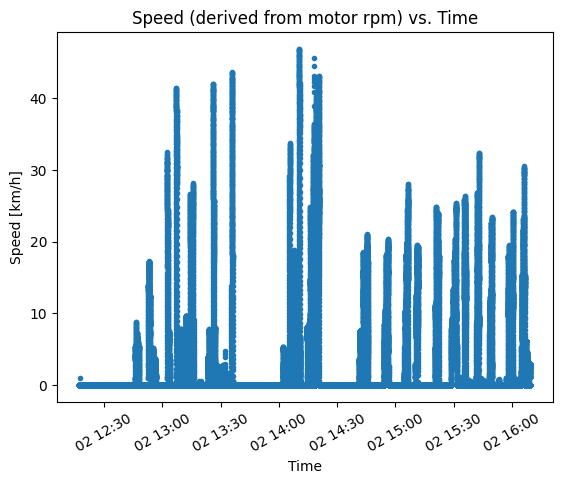

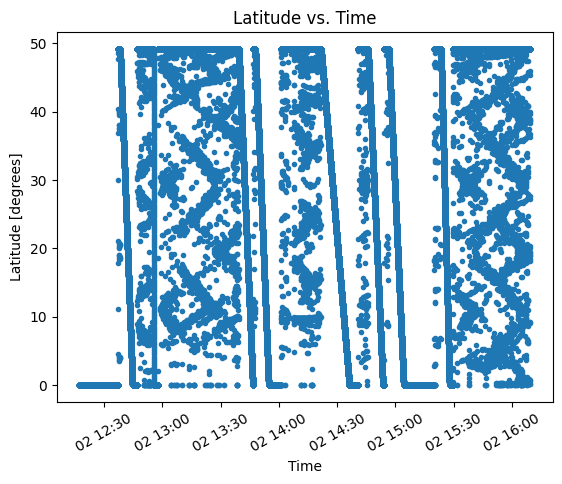

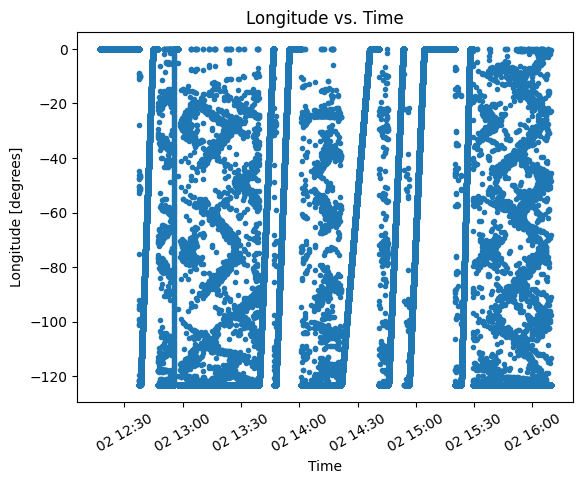

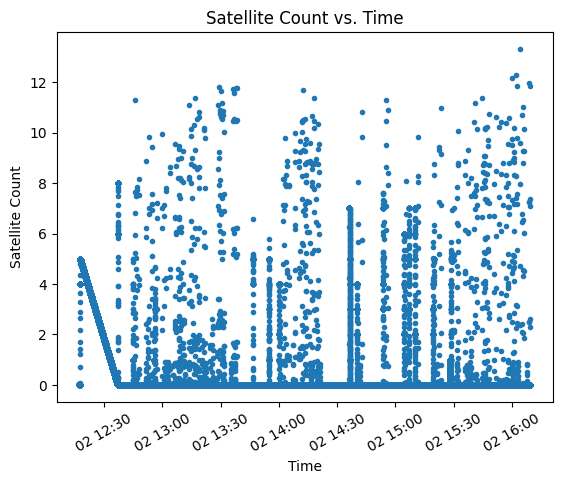

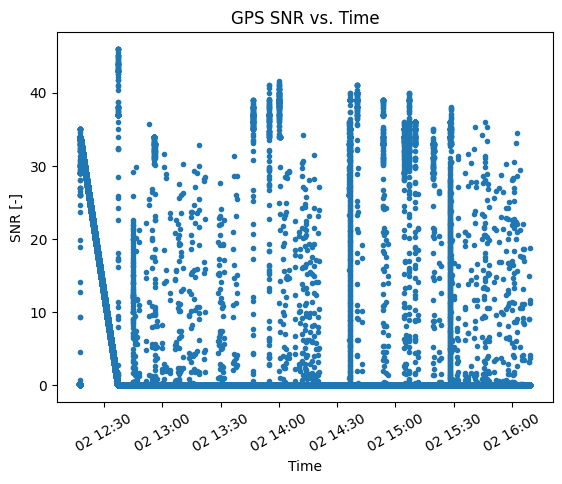

In [23]:
plt.scatter(dt_axis, speed_kph, marker='.')
plt.title("Speed (derived from motor rpm) vs. Time")
plt.xlabel("Time")
plt.xticks(rotation=30)
plt.ylabel("Speed [km/h]")
plt.show()

plt.scatter(dt_axis, latitude, marker='.')
plt.title("Latitude vs. Time")
plt.xlabel("Time")
plt.xticks(rotation=30)
plt.ylabel("Latitude [degrees]")
plt.show()

plt.scatter(dt_axis, longitude, marker='.')
plt.title("Longitude vs. Time")
plt.xlabel("Time")
plt.xticks(rotation=30)
plt.ylabel("Longitude [degrees]")
plt.show()

plt.scatter(dt_axis, sat_count, marker='.')
plt.title("Satellite Count vs. Time")
plt.xlabel("Time")
plt.xticks(rotation=30)
plt.ylabel("Satellite Count")
plt.show()

plt.scatter(dt_axis, gps_snr, marker='.')
plt.title("GPS SNR vs. Time")
plt.xlabel("Time")
plt.xticks(rotation=30)
plt.ylabel("SNR [-]")
plt.show()

## Filtering the GPS data

The latitude and longitude data is sometimes zero, which results in messed up values during interpolation when converting to TimeSeries.

The solution is to query the raw dataframe, filter out zeros and then convert to TimeSeries manually.

In [86]:
import pandas as pd


latitude_df: pd.DataFrame = client.query_series(
    driving_day_start,
    driving_day_end,
    "GPSLatitude",
)
longitude_df: pd.DataFrame = client.query_series(
    driving_day_start,
    driving_day_end,
    "GPSLongitude",
)

display(latitude_df)
display(longitude_df)

,result,table,_start,_stop,_time,_measurement,car,class,GPSLatitude
0,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:48.892000+00:00,TEL,Brightside,GPSPosition,0.000000
1,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.145000+00:00,TEL,Brightside,GPSPosition,0.000000
2,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.397000+00:00,TEL,Brightside,GPSPosition,0.000000
3,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.650000+00:00,TEL,Brightside,GPSPosition,0.000000
4,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.902000+00:00,TEL,Brightside,GPSPosition,0.000000
...,...,...,...,...,...,...,...,...,...
29779,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:21.877000+00:00,TEL,Brightside,GPSPosition,0.000000
29780,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:22.421000+00:00,TEL,Brightside,GPSPosition,49.198734
29781,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:22.672000+00:00,TEL,Brightside,GPSPosition,49.198734
29782,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:22.926000+00:00,TEL,Brightside,GPSPosition,49.198734


,result,table,_start,_stop,_time,_measurement,car,class,GPSLongitude
0,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:48.892000+00:00,TEL,Brightside,GPSPosition,0.000000
1,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.145000+00:00,TEL,Brightside,GPSPosition,0.000000
2,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.397000+00:00,TEL,Brightside,GPSPosition,0.000000
3,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.650000+00:00,TEL,Brightside,GPSPosition,0.000000
4,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.902000+00:00,TEL,Brightside,GPSPosition,0.000000
...,...,...,...,...,...,...,...,...,...
29779,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:21.877000+00:00,TEL,Brightside,GPSPosition,0.000000
29780,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:22.421000+00:00,TEL,Brightside,GPSPosition,123.145302
29781,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:22.672000+00:00,TEL,Brightside,GPSPosition,123.145302
29782,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:22.926000+00:00,TEL,Brightside,GPSPosition,123.145302


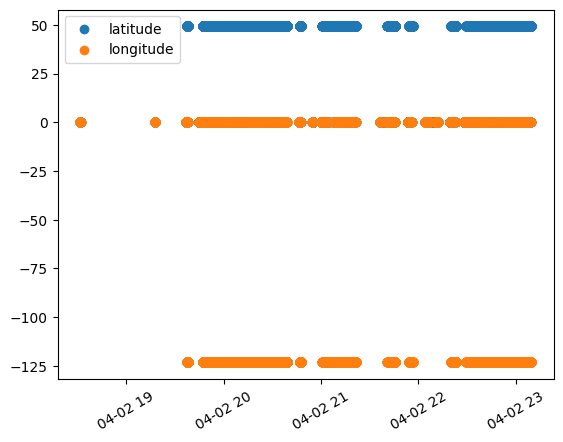

In [96]:
# Ensure they have the same time axis
assert np.all(latitude_df["_time"] == longitude_df["_time"])

latitude_df_dtxaxis = latitude_df.set_index(
    pd.to_datetime(latitude_df["_time"]).dt.tz_localize(None).dt.tz_localize('Etc/GMT+7').dt.tz_convert('UTC')
)
longitude_df_dtxaxis = longitude_df.set_index(
    pd.to_datetime(longitude_df["_time"]).dt.tz_localize(None).dt.tz_localize('Etc/GMT+7').dt.tz_convert('UTC')
)

gps_latlon_df_raw = latitude_df_dtxaxis[["GPSLatitude"]].join(longitude_df_dtxaxis[["GPSLongitude"]], how='inner')
gps_latlon_df_raw["GPSLongitude"] = -gps_latlon_df_raw["GPSLongitude"]

fig, ax = plt.subplots()
ax.scatter(gps_latlon_df_raw.index, gps_latlon_df_raw['GPSLatitude'], label='latitude')
ax.scatter(gps_latlon_df_raw.index, gps_latlon_df_raw['GPSLongitude'], label='longitude')
plt.xticks(rotation=30)
plt.legend(loc='best')
plt.show()

We can see above that the values are now either zero or in the correct range. We can also see that they are zero at the same time, i.e., when we have no fix.

Given this, the filtering is straight forward.

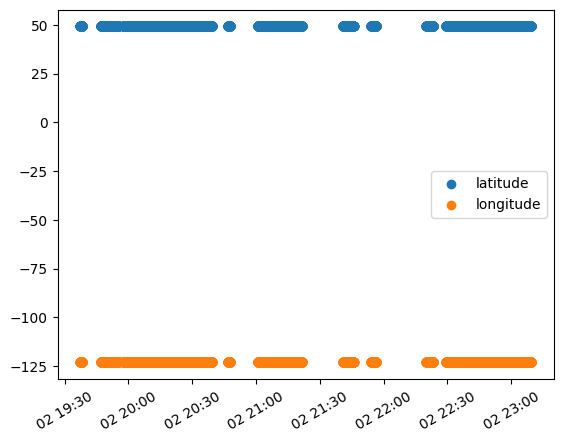

In [97]:
gps_latlon_df = gps_latlon_df_raw[(gps_latlon_df_raw['GPSLatitude'].abs() >= 0.1)
                                       & (gps_latlon_df_raw['GPSLongitude'].abs() >= 0.1)]

fig, ax = plt.subplots()
ax.scatter(gps_latlon_df.index, gps_latlon_df['GPSLatitude'], label='latitude')
ax.scatter(gps_latlon_df.index, gps_latlon_df['GPSLongitude'], label='longitude')
plt.xticks(rotation=30)
plt.legend(loc='best')
plt.show()

## Load Phone Data

This is data from my old cell phone, a Redmi Note 10 Pro (CN), with the GPSLogger app installed.

It was placed in the tow rope bag on the right hand side of the car. I occasionally pulled it out to check the data but otherwise it remained inside the vehicle at all times.

In [98]:
phone_gps_df = pd.read_csv('data/20260402.csv', parse_dates=['time'])
phone_gps_df = phone_gps_df.set_index(pd.to_datetime(phone_gps_df['time'], utc=True)).drop(columns=['time'])
phone_gps_df = phone_gps_df.rename(columns={'lat': 'GPSLatitude', 'lon': 'GPSLongitude'})

phone_gps_df.index = phone_gps_df.index.tz_convert('UTC')

phone_gps_df

,GPSLatitude,GPSLongitude,elevation,accuracy,bearing,speed,satellites,provider,hdop,vdop,...,dgpsid,activity,battery,annotation,timestamp_ms,time_offset,distance,starttimestamp_ms,profile_name,battery_charging
time,,,,,,,,,,,,,,,,,,,,,
2026-04-02 15:37:00.705000+00:00,49.198326,-123.141634,-14.3,29.894,NaN,NaN,0,network,NaN,NaN,...,NaN,NaN,97,NaN,1775144220705,2026-04-02T08:37:00.705-07:00,0.000000,1775144220572,Default Profile,False
2026-04-02 15:37:08.255000+00:00,49.198198,-123.142273,-54.1,10.000,301.11,2.398091,7,gps,2.20,0.96,...,NaN,NaN,97,NaN,1775144228255,2026-04-02T08:37:08.255-07:00,48.546146,1775144220572,Default Profile,False
2026-04-02 15:37:14.051000+00:00,49.198240,-123.142112,-53.8,10.600,292.22,0.131254,6,gps,1.61,0.93,...,NaN,NaN,97,NaN,1775144234051,2026-04-02T08:37:14.051-07:00,61.173478,1775144220572,Default Profile,False
2026-04-02 15:37:19.774000+00:00,49.198258,-123.142022,-61.8,10.500,318.50,2.168525,8,gps,1.54,0.96,...,NaN,NaN,97,NaN,1775144239774,2026-04-02T08:37:19.774-07:00,68.023230,1775144220572,Default Profile,False
2026-04-02 15:37:25.449000+00:00,49.198260,-123.141987,-63.4,10.400,339.27,0.180668,8,gps,1.22,0.84,...,NaN,NaN,97,NaN,1775144245449,2026-04-02T08:37:25.449-07:00,70.573060,1775144220572,Default Profile,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-02 23:15:32+00:00,49.198688,-123.145485,-23.6,1.300,64.14,0.000000,44,gps,0.39,0.52,...,0.0,NaN,80,NaN,1775171732000,2026-04-02T16:15:32.000-07:00,21020.905981,1775144256238,Default Profile,False
2026-04-02 23:15:34+00:00,49.198688,-123.145485,-23.6,1.300,64.14,0.000000,45,gps,0.38,0.52,...,0.0,NaN,80,NaN,1775171734000,2026-04-02T16:15:34.000-07:00,21020.905981,1775144256238,Default Profile,False
2026-04-02 23:15:36+00:00,49.198688,-123.145485,-23.6,1.300,64.14,0.000000,45,gps,0.38,0.52,...,0.0,NaN,80,NaN,1775171736000,2026-04-02T16:15:36.000-07:00,21020.905981,1775144256238,Default Profile,False


## Compare on Satellite Map

In [117]:
import folium

center = [gps_latlon_df['GPSLatitude'].mean(), gps_latlon_df['GPSLongitude'].mean()]

m = folium.Map(location=center, zoom_start=18, max_zoom=21, tiles='Esri.WorldImagery')

# Plot TEL GPS [RED]
folium.PolyLine(
    locations=gps_latlon_df[['GPSLatitude', 'GPSLongitude']].values.tolist(),
    color='red',
    weight=3,
    opacity=0.9
).add_to(m)

# Plot phone GPS [CYAN]
folium.PolyLine(
    locations=phone_gps_df[['GPSLatitude', 'GPSLongitude']].values.tolist(),
    color='cyan',
    weight=3,
    opacity=0.9
).add_to(m)

m

## Compare on Time-Domain

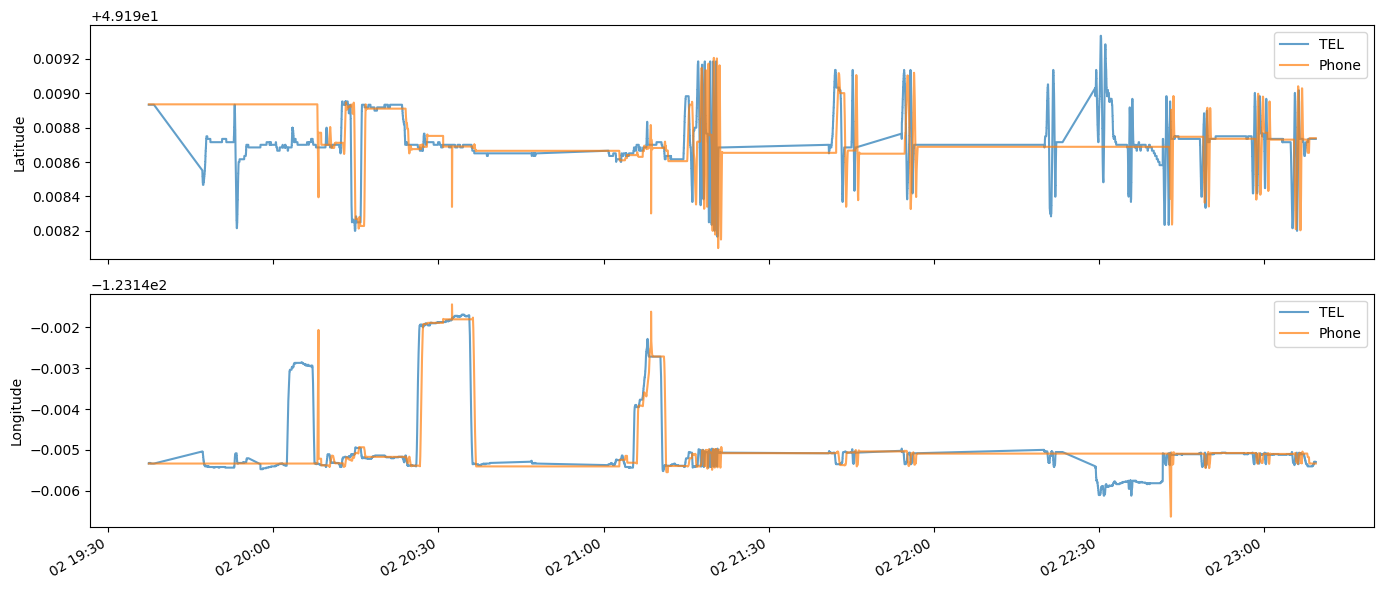

In [103]:
def compare_phone_tel(start, end):
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    axes[0].plot(gps_latlon_df.loc[start:end].index, gps_latlon_df.loc[start:end]['GPSLatitude'], label='TEL', alpha=0.7)
    axes[0].plot(phone_gps_df.loc[start:end].index, phone_gps_df.loc[start:end]['GPSLatitude'], label='Phone', alpha=0.7)
    axes[0].set_ylabel('Latitude')
    axes[0].legend()

    axes[1].plot(gps_latlon_df.loc[start:end].index, gps_latlon_df.loc[start:end]['GPSLongitude'], label='TEL', alpha=0.7)
    axes[1].plot(phone_gps_df.loc[start:end].index, phone_gps_df.loc[start:end]['GPSLongitude'], label='Phone', alpha=0.7)
    axes[1].set_ylabel('Longitude')
    axes[1].legend()

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

start = max(gps_latlon_df.index.min(), phone_gps_df.index.min())
end = min(gps_latlon_df.index.max(), phone_gps_df.index.max())

compare_phone_tel(start, end)

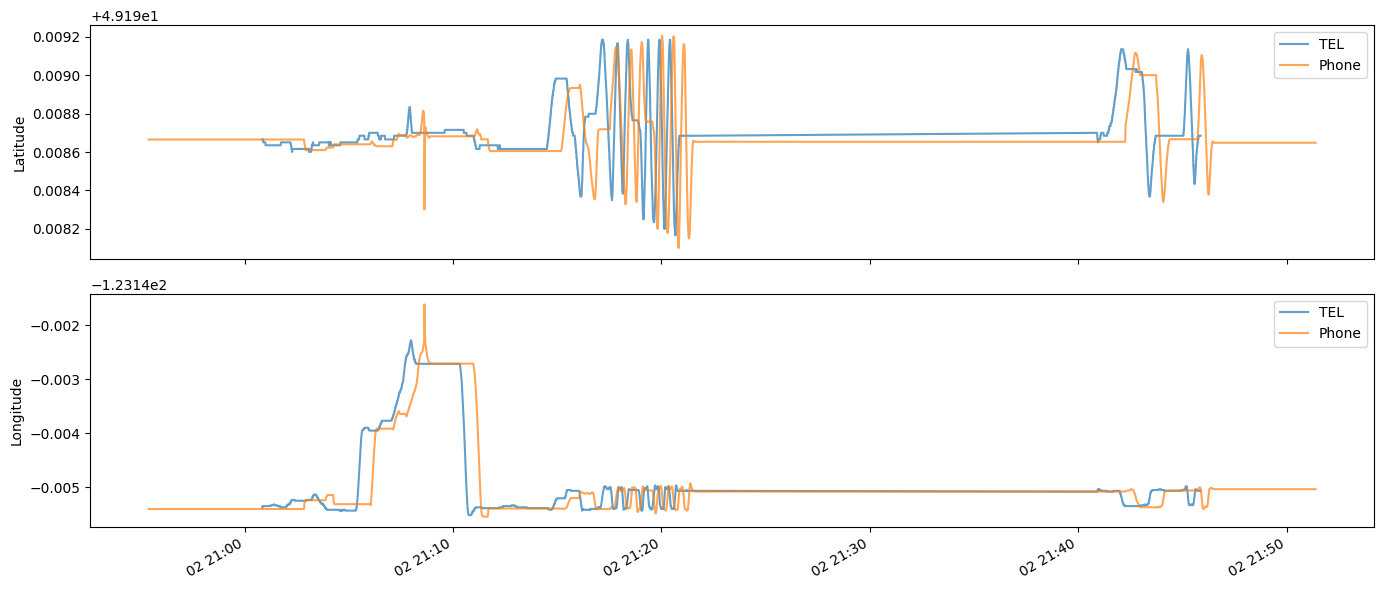

In [107]:
from datetime import timedelta

compare_phone_tel(start + timedelta(0, 3600*1.3), end - timedelta(0, 3600*1.3))

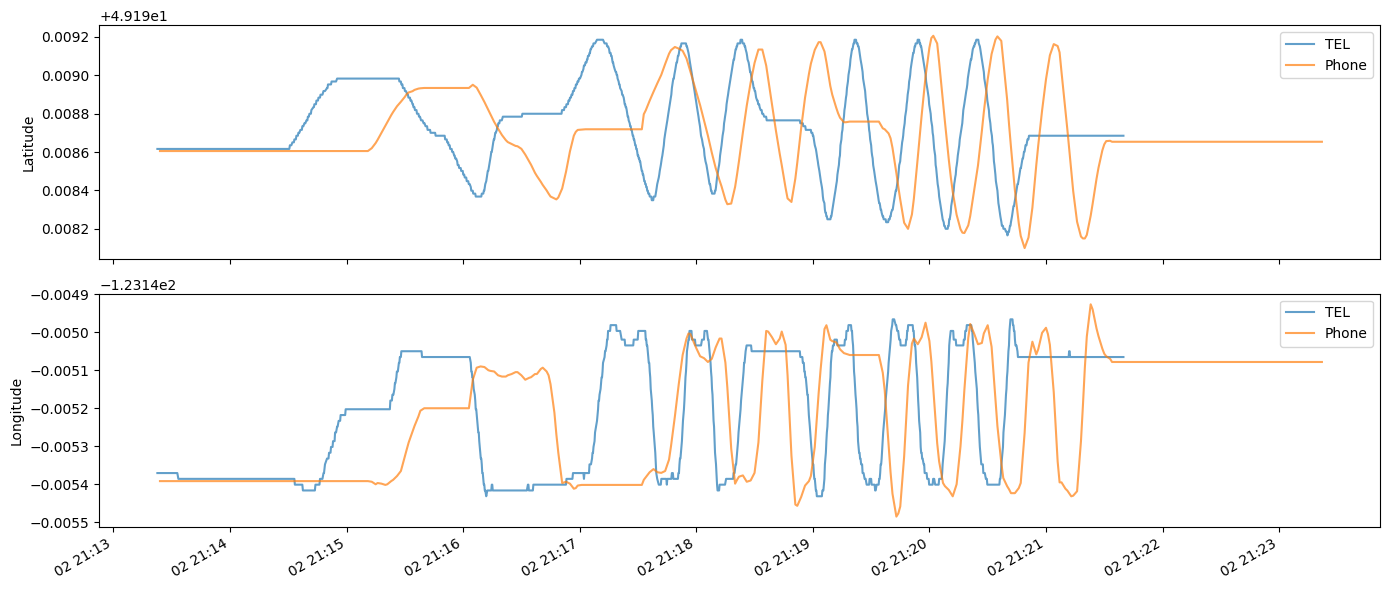

In [114]:
sample_start = start + timedelta(0, 3600*1.6)
compare_phone_tel(sample_start, sample_start + timedelta(0, 10*60))

There is a notable time shift between the phone's values and the TEL GPS values. We can compute the best fit time shift by maximizing the cross-correlation of the two signals.

## Find & Correct the Time Shift

In [115]:
import numpy as np
from scipy.interpolate import interp1d

# Common time grid at 1-second resolution
t_start = max(gps_latlon_df.index.min(), phone_gps_df.index.min())
t_end = min(gps_latlon_df.index.max(), phone_gps_df.index.max())
t_grid = pd.date_range(t_start, t_end, freq='1s')
t_seconds = np.arange(len(t_grid))

# Interpolate both onto the common grid using latitude
def interpolate_to_grid(df, col, t_grid):
    t_ns = df.index.astype(np.int64)
    t_grid_ns = t_grid.astype(np.int64)
    f = interp1d(t_ns, df[col].values, bounds_error=False, fill_value=np.nan)
    return f(t_grid_ns)

tel_lat = interpolate_to_grid(gps_latlon_df, 'GPSLatitude', t_grid)
phone_lat = interpolate_to_grid(phone_gps_df, 'GPSLatitude', t_grid)

# Mask NaNs
mask = ~np.isnan(tel_lat) & ~np.isnan(phone_lat)
a = tel_lat[mask] - tel_lat[mask].mean()
b = phone_lat[mask] - phone_lat[mask].mean()

# Cross-correlation
corr = np.correlate(a, b, mode='full')
lag = np.argmax(corr) - (len(b) - 1)

print(f"Time shift: {lag} seconds (positive = TEL is ahead of Phone)")

Time shift: -39 seconds (positive = TEL is ahead of Phone)


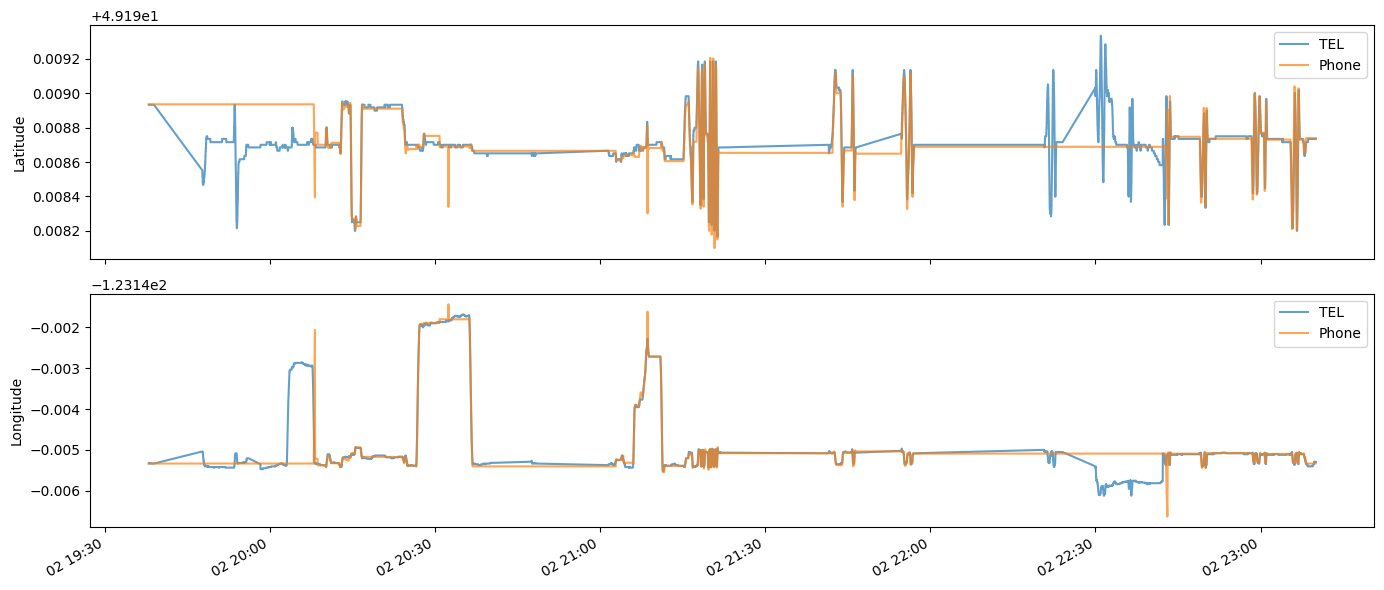

In [119]:
gps_latlon_df_aligned = gps_latlon_df.copy()
gps_latlon_df_aligned.index = gps_latlon_df_aligned.index - pd.Timedelta(seconds=lag)

start = max(gps_latlon_df_aligned.index.min(), phone_gps_df.index.min())
end = min(gps_latlon_df_aligned.index.max(), phone_gps_df.index.max())

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(gps_latlon_df_aligned.loc[start:end].index, gps_latlon_df_aligned.loc[start:end]['GPSLatitude'], label='TEL', alpha=0.7)
axes[0].plot(phone_gps_df.loc[start:end].index, phone_gps_df.loc[start:end]['GPSLatitude'], label='Phone', alpha=0.7)
axes[0].set_ylabel('Latitude')
axes[0].legend()

axes[1].plot(gps_latlon_df_aligned.loc[start:end].index, gps_latlon_df_aligned.loc[start:end]['GPSLongitude'], label='TEL', alpha=0.7)
axes[1].plot(phone_gps_df.loc[start:end].index, phone_gps_df.loc[start:end]['GPSLongitude'], label='Phone', alpha=0.7)
axes[1].set_ylabel('Longitude')
axes[1].legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()